## Imports and Setup

In [9]:
import os
import random
import warnings
import numpy as np
import polars as pl
import scipy
import scipy.stats as stats
import sklearn
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import plotly.io as pio

pio.renderers.default = "png"
pio.defaults.default_scale = 2

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"numpy       {np.__version__}")
print(f"polars      {pl.__version__}")
print(f"scipy       {scipy.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"plotly      {plotly.__version__}")

numpy       2.5.2
polars      1.43.2
scipy       1.18.0
scikit-learn 1.9.0
plotly      6.9.0


## Loading Processed Data

In [3]:
PROCESSED_DATA_DIR = "../data/processed"

X_train = pl.read_parquet(f"{PROCESSED_DATA_DIR}/X_train_encoded.parquet")
X_test = pl.read_parquet(f"{PROCESSED_DATA_DIR}/X_test_encoded.parquet")
y_train = pl.read_parquet(f"{PROCESSED_DATA_DIR}/y_train.parquet")
y_test = pl.read_parquet(f"{PROCESSED_DATA_DIR}/y_test.parquet")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (137, 71), X_test: (68, 71)
y_train: (137, 2), y_test: (68, 2)


## Verifying Column Alignment Between Train and Test

In [4]:
train_cols = X_train.columns
test_cols = X_test.columns

print(f"Same columns, same order: {train_cols == test_cols}")

if train_cols != test_cols:
    only_train = set(train_cols) - set(test_cols)
    only_test = set(test_cols) - set(train_cols)
    print(f"Only in train: {only_train}")
    print(f"Only in test: {only_test}")

Same columns, same order: True


## Preparing Both Regression Targets

In [5]:
y_train_price = y_train["price"].to_numpy()
y_test_price = y_test["price"].to_numpy()

y_train_log = y_train["price_log"].to_numpy()
y_test_log = y_test["price_log"].to_numpy()

print(f"y_train_price: {y_train_price.shape}, y_test_price: {y_test_price.shape}")
print(f"y_train_log: {y_train_log.shape}, y_test_log: {y_test_log.shape}")

y_train_price: (137,), y_test_price: (68,)
y_train_log: (137,), y_test_log: (68,)


## OLS Baseline: Pipeline Setup and Fit on Both Targets

In [6]:
ols_pipeline_price = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
ols_pipeline_price.fit(X_train, y_train_price)

ols_pipeline_log = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
ols_pipeline_log.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](71,)","['carlength','carwidth','carheight',...,'brand_toyota','brand_volkswagen', 'brand_volvo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,71
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


## OLS Baseline: Metrics on Both Targets

In [7]:
pred_train_price = ols_pipeline_price.predict(X_train)
pred_test_price = ols_pipeline_price.predict(X_test)

pred_train_log = ols_pipeline_log.predict(X_train)
pred_test_log = ols_pipeline_log.predict(X_test)

pred_train_log_dollar = np.expm1(pred_train_log)
pred_test_log_dollar = np.expm1(pred_test_log)

metrics = pl.DataFrame({
    "model": ["OLS (price)", "OLS (price)", "OLS (price_log, back-transformed)", "OLS (price_log, back-transformed)"],
    "set": ["train", "test", "train", "test"],
    "rmse": [
        root_mean_squared_error(y_train_price, pred_train_price),
        root_mean_squared_error(y_test_price, pred_test_price),
        root_mean_squared_error(y_train_price, pred_train_log_dollar),
        root_mean_squared_error(y_test_price, pred_test_log_dollar),
    ],
    "r2": [
        r2_score(y_train_price, pred_train_price),
        r2_score(y_test_price, pred_test_price),
        r2_score(y_train_price, pred_train_log_dollar),
        r2_score(y_test_price, pred_test_log_dollar),
    ],
})

metrics

model,set,rmse,r2
str,str,f64,f64
"""OLS (price)""","""train""",1247.396619,0.975086
"""OLS (price)""","""test""",2776.779727,0.882166
"""OLS (price_log, back-transform…","""train""",1167.274857,0.978184
"""OLS (price_log, back-transform…","""test""",2048.685447,0.935859


## OLS Residual Diagnostics: Price vs Price_log

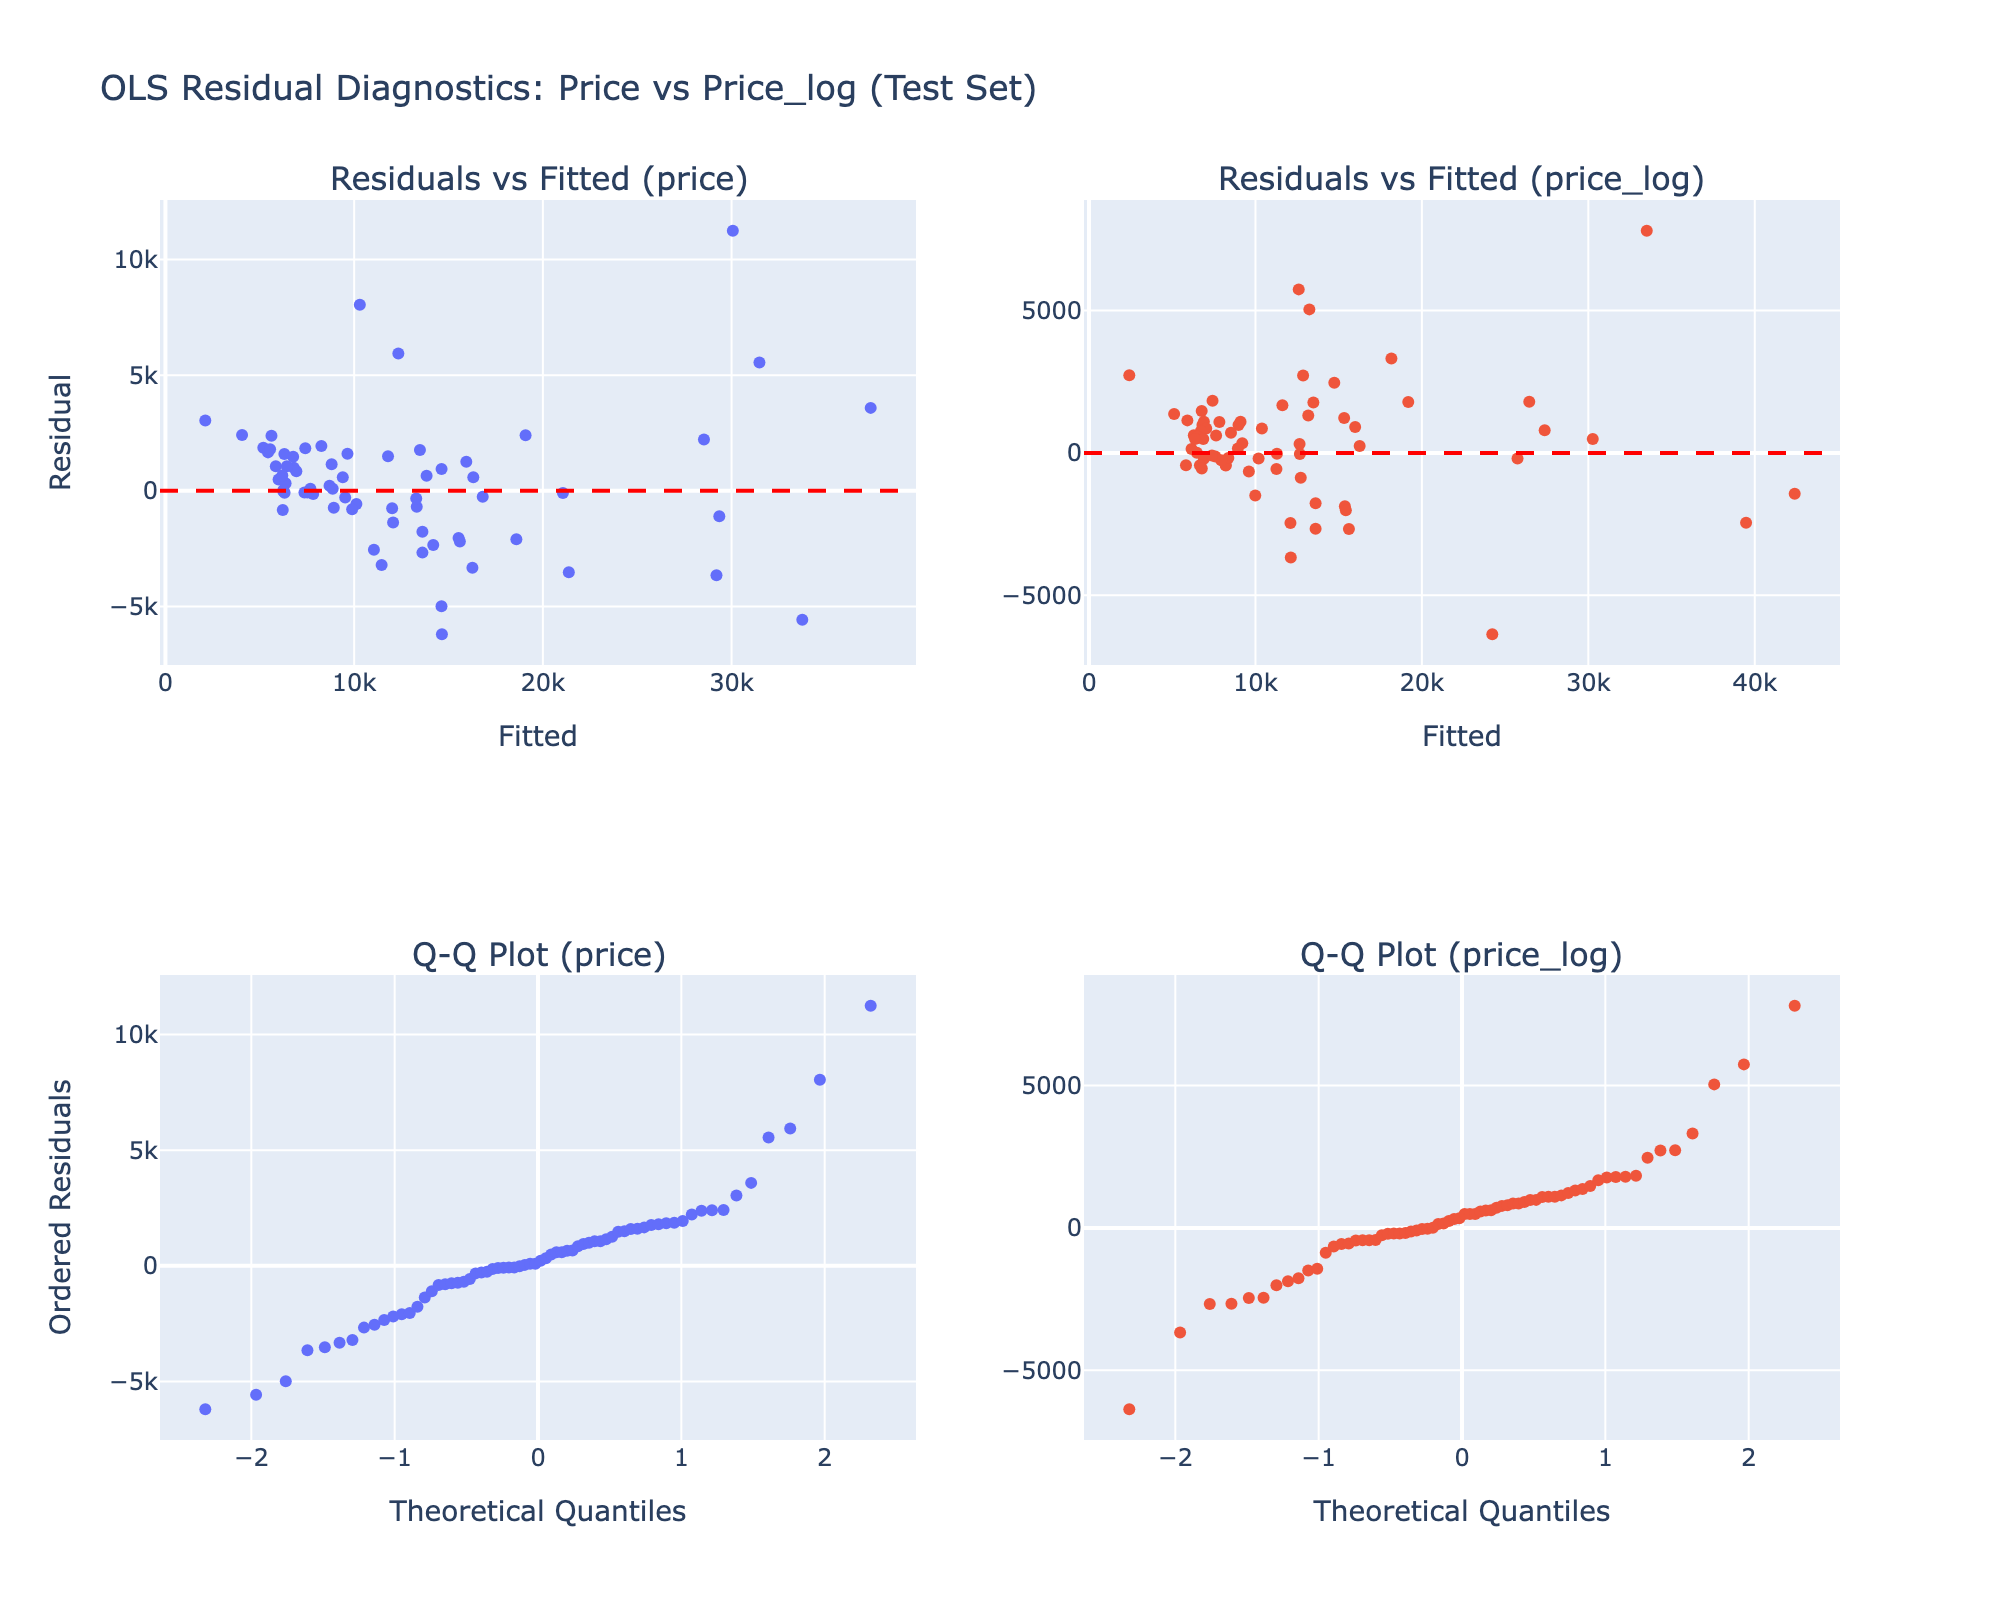

In [10]:
residuals_price = y_test_price - pred_test_price
residuals_log_dollar = y_test_price - pred_test_log_dollar

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "Residuals vs Fitted (price)", "Residuals vs Fitted (price_log)",
        "Q-Q Plot (price)", "Q-Q Plot (price_log)"
    ]
)

fig.add_trace(
    go.Scatter(x=pred_test_price, y=residuals_price, mode="markers",
               marker_color="#636EFA", showlegend=False),
    row=1, col=1
)
fig.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=1)

fig.add_trace(
    go.Scatter(x=pred_test_log_dollar, y=residuals_log_dollar, mode="markers",
               marker_color="#EF553B", showlegend=False),
    row=1, col=2
)
fig.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=2)

qq_price = stats.probplot(residuals_price, dist="norm")
qq_log = stats.probplot(residuals_log_dollar, dist="norm")

fig.add_trace(
    go.Scatter(x=qq_price[0][0], y=qq_price[0][1], mode="markers",
               marker_color="#636EFA", showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=qq_log[0][0], y=qq_log[0][1], mode="markers",
               marker_color="#EF553B", showlegend=False),
    row=2, col=2
)

fig.update_xaxes(title_text="Fitted", row=1, col=1)
fig.update_xaxes(title_text="Fitted", row=1, col=2)
fig.update_yaxes(title_text="Residual", col=1)
fig.update_xaxes(title_text="Theoretical Quantiles", row=2, col=1)
fig.update_xaxes(title_text="Theoretical Quantiles", row=2, col=2)
fig.update_yaxes(title_text="Ordered Residuals", col=1, row=2)

fig.update_layout(
    title="OLS Residual Diagnostics: Price vs Price_log (Test Set)",
    height=800,
    width=1000
)

fig.write_image("../reports/figures/13_ols_residual_diagnostics.png")
fig.show()

## Ridge Regression: Pipeline and GridSearchCV

In [11]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Ridge())
])

ridge_param_grid = {
    "regressor__alpha": np.logspace(-3, 3, 50)
}

ridge_grid_search = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid_search.fit(X_train, y_train_log)

print(f"Best alpha: {ridge_grid_search.best_params_['regressor__alpha']:.4f}")
print(f"Best CV RMSE (log scale): {-ridge_grid_search.best_score_:.4f}")

Best alpha: 25.5955
Best CV RMSE (log scale): 0.1378


## Ridge Regression: Train and Test Evaluation

In [12]:
pred_train_ridge_log = ridge_grid_search.predict(X_train)
pred_test_ridge_log = ridge_grid_search.predict(X_test)

pred_train_ridge_dollar = np.exp(pred_train_ridge_log)
pred_test_ridge_dollar = np.exp(pred_test_ridge_log)

ridge_metrics = pl.DataFrame({
    "model": ["Ridge", "Ridge"],
    "set": ["train", "test"],
    "rmse_log": [
        root_mean_squared_error(y_train_log, pred_train_ridge_log),
        root_mean_squared_error(y_test_log, pred_test_ridge_log),
    ],
    "rmse_dollar": [
        root_mean_squared_error(y_train_price, pred_train_ridge_dollar),
        root_mean_squared_error(y_test_price, pred_test_ridge_dollar),
    ],
    "r2": [
        r2_score(y_train_price, pred_train_ridge_dollar),
        r2_score(y_test_price, pred_test_ridge_dollar),
    ],
})

ridge_metrics

model,set,rmse_log,rmse_dollar,r2
str,str,f64,f64,f64
"""Ridge""","""train""",0.097795,1277.650473,0.973863
"""Ridge""","""test""",0.143424,2221.28155,0.924596


## Lasso Regression: Pipeline and GridSearchCV

In [13]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Lasso(max_iter=10000))
])

lasso_param_grid = {
    "regressor__alpha": np.logspace(-4, 1, 50)
}

lasso_grid_search = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid_search.fit(X_train, y_train_log)

print(f"Best alpha: {lasso_grid_search.best_params_['regressor__alpha']:.6f}")
print(f"Best CV RMSE (log scale): {-lasso_grid_search.best_score_:.4f}")

Best alpha: 0.006866
Best CV RMSE (log scale): 0.1423


## Lasso Regression: Train and Test Evaluation

In [14]:
pred_train_lasso_log = lasso_grid_search.predict(X_train)
pred_test_lasso_log = lasso_grid_search.predict(X_test)

pred_train_lasso_dollar = np.exp(pred_train_lasso_log)
pred_test_lasso_dollar = np.exp(pred_test_lasso_log)

lasso_metrics = pl.DataFrame({
    "model": ["Lasso", "Lasso"],
    "set": ["train", "test"],
    "rmse_log": [
        root_mean_squared_error(y_train_log, pred_train_lasso_log),
        root_mean_squared_error(y_test_log, pred_test_lasso_log),
    ],
    "rmse_dollar": [
        root_mean_squared_error(y_train_price, pred_train_lasso_dollar),
        root_mean_squared_error(y_test_price, pred_test_lasso_dollar),
    ],
    "r2": [
        r2_score(y_train_price, pred_train_lasso_dollar),
        r2_score(y_test_price, pred_test_lasso_dollar),
    ],
})

lasso_metrics

model,set,rmse_log,rmse_dollar,r2
str,str,f64,f64,f64
"""Lasso""","""train""",0.099327,1438.613125,0.966863
"""Lasso""","""test""",0.141893,1979.342328,0.940127


## Lasso Coefficient Sparsity

In [15]:
lasso_coefs = lasso_grid_search.best_estimator_.named_steps["regressor"].coef_
feature_names = X_train.columns

n_zero = np.sum(lasso_coefs == 0)
n_nonzero = np.sum(lasso_coefs != 0)

print(f"Total features: {len(lasso_coefs)}")
print(f"Zeroed out: {n_zero}")
print(f"Retained: {n_nonzero}")

zeroed_features = [name for name, coef in zip(feature_names, lasso_coefs) if coef == 0]
print(f"\nZeroed features: {zeroed_features}")

Total features: 71
Zeroed out: 34
Retained: 37

Zeroed features: ['carheight', 'boreratio', 'stroke', 'peakrpm', 'highwaympg', 'wheelbase_log', 'enginesize_log', 'symboling_encoded', 'fueltype_diesel', 'fueltype_gas', 'doornumber_four', 'doornumber_two', 'carbody_sedan', 'drivewheel_4wd', 'drivewheel_rwd', 'enginetype_dohc', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv', 'cylindernumber_eight', 'cylindernumber_five', 'cylindernumber_four', 'cylindernumber_other', 'cylindernumber_six', 'fuelsystem_1bbl', 'fuelsystem_4bbl', 'fuelsystem_idi', 'fuelsystem_other', 'fuelsystem_spdi', 'brand_chevrolet', 'brand_honda', 'brand_isuzu', 'brand_mazda', 'brand_volkswagen']


## Multicollinearity Case Study Revisited: Ridge vs Lasso on citympg, highwaympg, curbweight

In [17]:
ridge_coefs = ridge_grid_search.best_estimator_.named_steps["regressor"].coef_

case_study_cols = ["citympg", "highwaympg", "curbweight"]
case_study_idx = [list(feature_names).index(col) for col in case_study_cols]

case_study_compare = pl.DataFrame({
    "feature": case_study_cols,
    "ridge_coef": [ridge_coefs[i] for i in case_study_idx],
    "lasso_coef": [lasso_coefs[i] for i in case_study_idx],
})

case_study_compare

feature,ridge_coef,lasso_coef
str,f64,f64
"""citympg""",-0.033175,-0.005244
"""highwaympg""",-0.019233,-0.0
"""curbweight""",0.062736,0.223043


## Visualizing the Multicollinearity Case Study Result

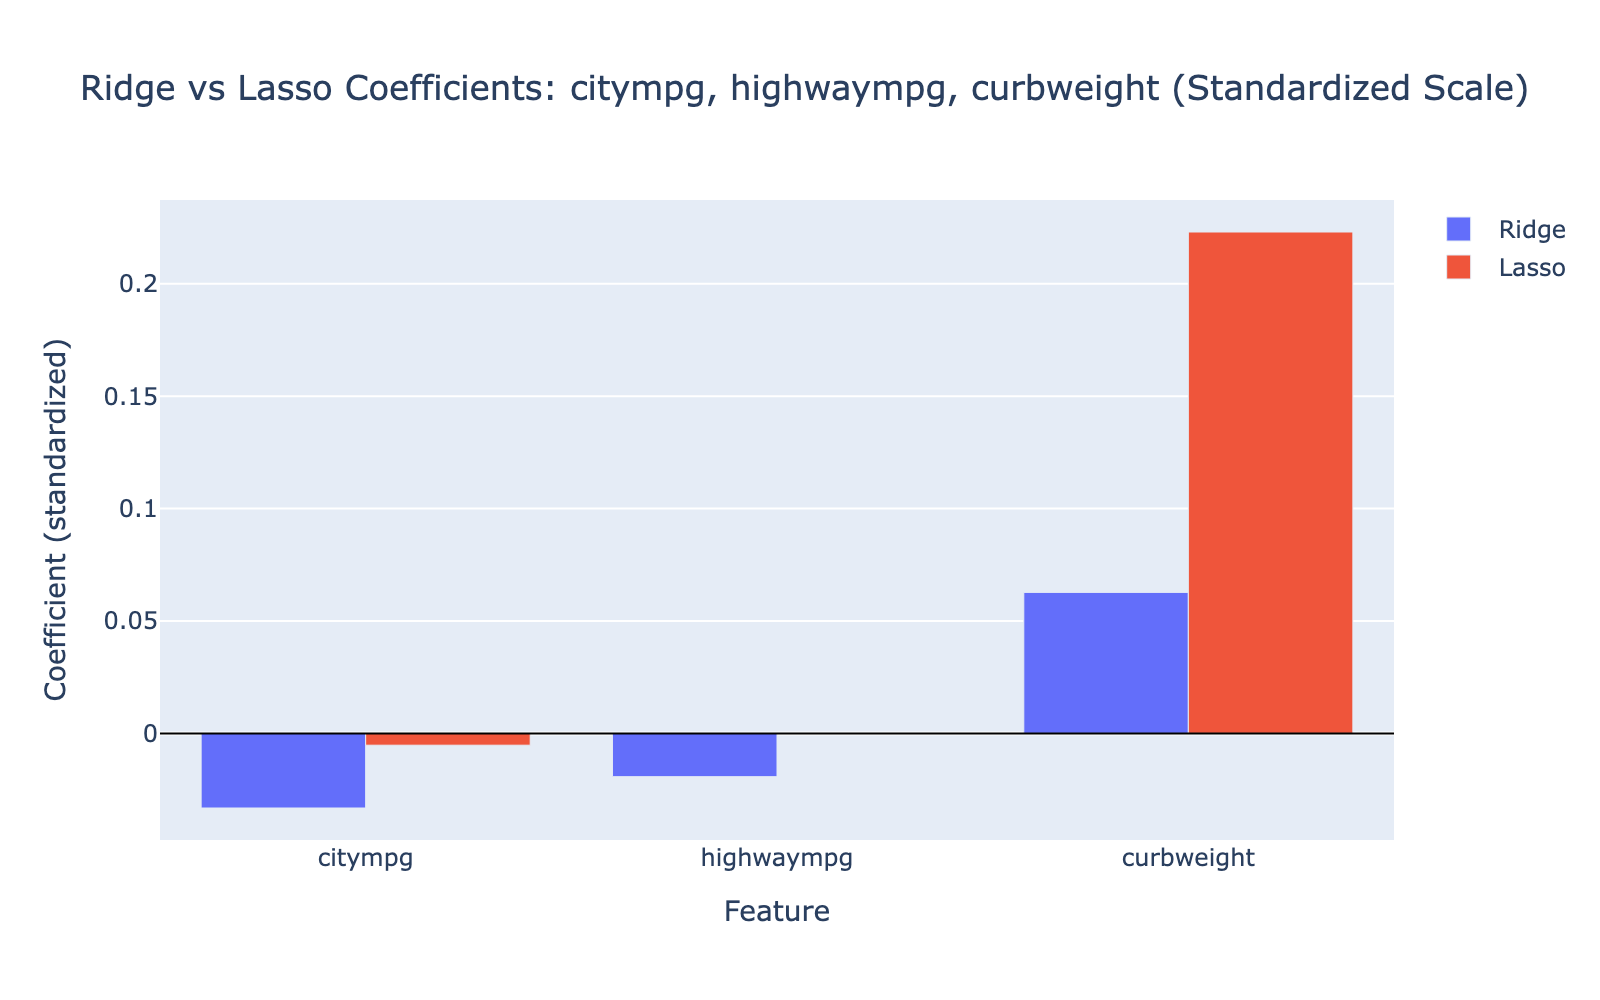

In [18]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=case_study_compare["feature"],
    y=case_study_compare["ridge_coef"],
    name="Ridge",
    marker_color="#636EFA"
))
fig.add_trace(go.Bar(
    x=case_study_compare["feature"],
    y=case_study_compare["lasso_coef"],
    name="Lasso",
    marker_color="#EF553B"
))

fig.add_hline(y=0, line_color="black", line_width=1)

fig.update_layout(
    title="Ridge vs Lasso Coefficients: citympg, highwaympg, curbweight (Standardized Scale)",
    xaxis_title="Feature",
    yaxis_title="Coefficient (standardized)",
    barmode="group",
    height=500,
    width=800
)

fig.write_image("../reports/figures/14_ridge_vs_lasso_multicollinearity.png")
fig.show()

## Lasso Convergence Check

In [19]:
lasso_best_model = lasso_grid_search.best_estimator_.named_steps["regressor"]

print(f"n_iter_: {lasso_best_model.n_iter_}")
print(f"max_iter: {lasso_best_model.max_iter}")
print(f"Converged: {lasso_best_model.n_iter_ < lasso_best_model.max_iter}")

n_iter_: 98
max_iter: 10000
Converged: True


## Alpha Stability Check: Ridge and Lasso CV Score Curves

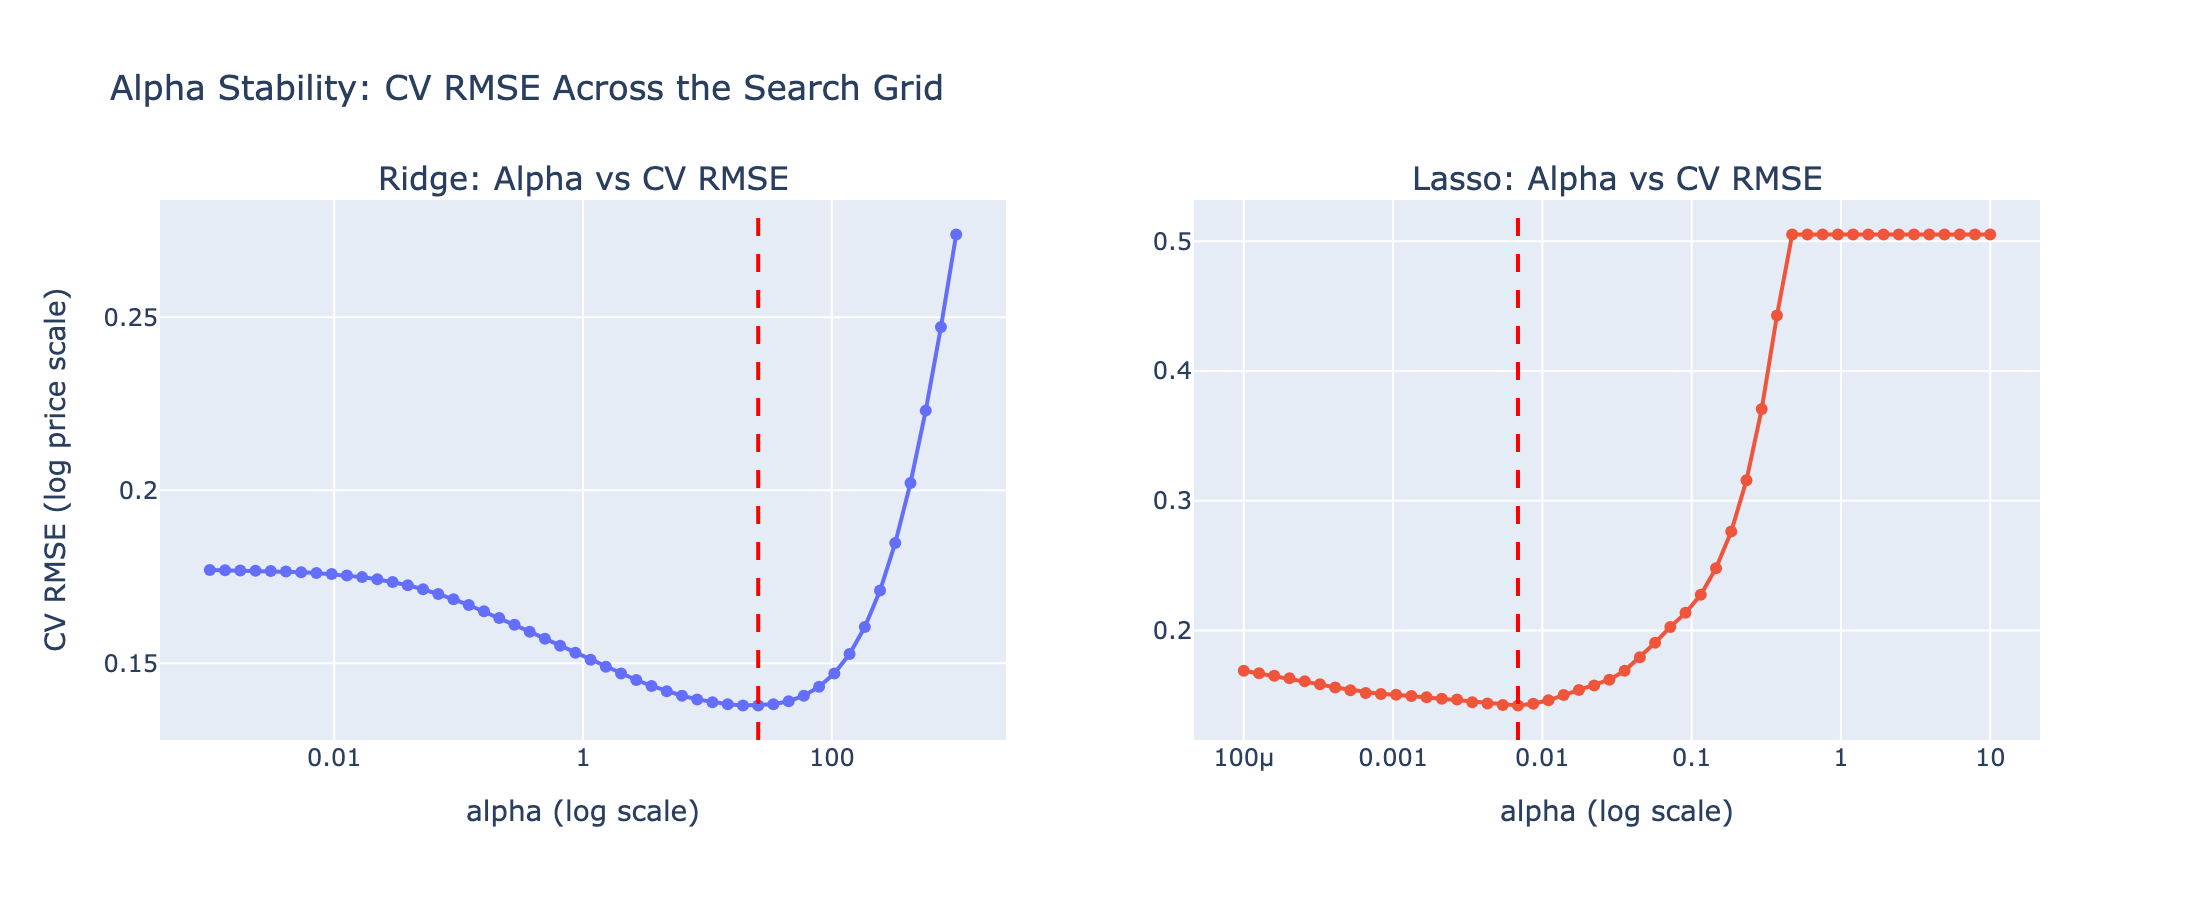

In [20]:
ridge_cv_results = pl.DataFrame({
    "alpha": ridge_grid_search.cv_results_["param_regressor__alpha"].data.astype(float),
    "mean_test_rmse": -ridge_grid_search.cv_results_["mean_test_score"],
})

lasso_cv_results = pl.DataFrame({
    "alpha": lasso_grid_search.cv_results_["param_regressor__alpha"].data.astype(float),
    "mean_test_rmse": -lasso_grid_search.cv_results_["mean_test_score"],
})

fig = make_subplots(rows=1, cols=2, subplot_titles=["Ridge: Alpha vs CV RMSE", "Lasso: Alpha vs CV RMSE"])

fig.add_trace(
    go.Scatter(x=ridge_cv_results["alpha"], y=ridge_cv_results["mean_test_rmse"],
               mode="lines+markers", marker_color="#636EFA", showlegend=False),
    row=1, col=1
)
fig.add_vline(x=ridge_grid_search.best_params_["regressor__alpha"],
              line_dash="dash", line_color="red", row=1, col=1)

fig.add_trace(
    go.Scatter(x=lasso_cv_results["alpha"], y=lasso_cv_results["mean_test_rmse"],
               mode="lines+markers", marker_color="#EF553B", showlegend=False),
    row=1, col=2
)
fig.add_vline(x=lasso_grid_search.best_params_["regressor__alpha"],
              line_dash="dash", line_color="red", row=1, col=2)

fig.update_xaxes(title_text="alpha (log scale)", type="log", row=1, col=1)
fig.update_xaxes(title_text="alpha (log scale)", type="log", row=1, col=2)
fig.update_yaxes(title_text="CV RMSE (log price scale)", col=1)

fig.update_layout(
    title="Alpha Stability: CV RMSE Across the Search Grid",
    height=450,
    width=1100
)

fig.write_image("../reports/figures/15_alpha_stability_check.png")
fig.show()

## Saving Fitted Models and Predictions to Disk

In [21]:
import joblib

MODEL_DIR = "../src_models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(ridge_grid_search.best_estimator_, f"{MODEL_DIR}/ridge_best_model.joblib")
joblib.dump(lasso_grid_search.best_estimator_, f"{MODEL_DIR}/lasso_best_model.joblib")

predictions = pl.DataFrame({
    "y_test_price": y_test_price,
    "pred_test_ols_log_dollar": pred_test_log_dollar,
    "pred_test_ridge_dollar": pred_test_ridge_dollar,
    "pred_test_lasso_dollar": pred_test_lasso_dollar,
})

predictions.write_parquet(f"{PROCESSED_DATA_DIR}/notebook3_test_predictions.parquet")

print(f"Saved ridge_best_model.joblib and lasso_best_model.joblib to {MODEL_DIR}")
print(f"Saved notebook3_test_predictions.parquet to {PROCESSED_DATA_DIR}")

Saved ridge_best_model.joblib and lasso_best_model.joblib to ../src_models
Saved notebook3_test_predictions.parquet to ../data/processed
